# FineWeb Data Exploration & Initial Cleaning – V1

**Author:** Xingyu Li 
**Team:** JoeyLLTeam  
**Version:** V1 (Exploration Phase)  
**Focus:** Data Exploration & Cleaning Practice  

## 1. Background

This notebook explores a subset of the FineWeb dataset (5–10 parquet files), instead of the full dataset (~60TB), which is not practical at this stage.

The focus is on working with a manageable sample to understand the data and experiment with basic processing.

---

本 notebook 基于 FineWeb 的小规模子集数据（5–10 个 parquet 文件）进行分析，而不是使用完整数据集（约60TB），以保证在当前阶段具有可操作性。

重点是在可控规模下理解数据并进行基础探索与处理尝试。

## 2. Objectives

- Perform basic data exploration  
- Understand schema and key columns  
- Identify anomalies and data issues  
- Experiment with simple cleaning approaches  
- Document reasoning and observations  

---

- 进行基础数据探索  
- 理解数据结构与字段含义  
- 识别异常与数据问题  
- 尝试初步清洗方法  
- 记录思考过程  

## 3. Data Scope and Plan

In this notebook, I first inspect the available parquet files and select one representative file for detailed exploration.  
After that, I expand the analysis to a small number of files to compare structure and consistency across shards.

This notebook is still an early exploration draft, so the goal is not to build a full pipeline, but to:
- understand file structure,
- inspect key columns,
- identify possible quality issues,
- try simple cleaning steps,
- document observations for future work.

---

### 中文
在本 notebook 中，我会先查看当前可用的 parquet 文件，并选取一个具有代表性的文件进行详细分析。  
之后，我会扩展到少量多个文件进行横向比较，以观察不同分片之间的结构和一致性。

当前仍属于早期探索版本，因此目标不是搭建完整 pipeline，而是：
- 理解文件结构，
- 检查关键字段，
- 识别潜在数据质量问题，
- 尝试基础清洗方法，
- 记录当前观察与后续思路。

In [26]:
# Install required packages for the remote Jupyter environment
!pip install pyarrow pandas matplotlib

In [27]:
# Standard imports
import os
import glob
import re

import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt

## 3. Locate Available Parquet Files

### English
The first step is to locate the available sample parquet files in the current environment.  
This helps define the actual scope of analysis and avoids relying on a single hard-coded path too early.

### 中文
第一步是定位当前环境中可用的 sample parquet 文件。  
这样可以先确认实际可分析的数据范围，而不是一开始就只依赖单个固定路径。

In [28]:
# Set your dataset directory here
data_dir = "data/fineweb"

# Find parquet files
parquet_files = sorted(glob.glob(os.path.join(data_dir, "*.parquet")))

print(f"Found {len(parquet_files)} parquet files.\n")

for i, fp in enumerate(parquet_files[:10], start=1):
    print(f"{i}. {fp}")

Found 10 parquet files.

1. data/fineweb/004_00018.parquet
2. data/fineweb/004_00019.parquet
3. data/fineweb/004_00020.parquet
4. data/fineweb/004_00021.parquet
5. data/fineweb/004_00022.parquet
6. data/fineweb/004_00023.parquet
7. data/fineweb/004_00046.parquet
8. data/fineweb/004_00047.parquet
9. data/fineweb/004_00048.parquet
10. data/fineweb/004_00049.parquet


## 4. Select One File for Detailed Inspection

### English
To keep the first-pass exploration manageable, I begin with one parquet file for detailed inspection.  
This allows me to understand metadata, schema, sample rows, and possible issues before expanding further.

### 中文
为了让第一轮探索更可控，我先选择一个 parquet 文件进行详细检查。  
这样可以先理解其元数据、schema、样本内容和潜在问题，再逐步扩展到更多文件。

In [29]:
# Select the first available parquet file
file_path = parquet_files[0]
print("Selected file:", file_path)

pf = pq.ParquetFile(file_path)

print("\nBasic metadata:")
print("Number of row groups:", pf.num_row_groups)
print("Number of rows:", pf.metadata.num_rows)
print("Number of columns:", pf.metadata.num_columns)

Selected file: data/fineweb/004_00018.parquet

Basic metadata:
Number of row groups: 173
Number of rows: 172447
Number of columns: 9


In [30]:
# Display parquet schema
print("Schema:")
print(pf.schema)

Schema:
required group field_id=-1 schema {
  optional binary field_id=-1 text (String);
  optional binary field_id=-1 id (String);
  optional binary field_id=-1 dump (String);
  optional binary field_id=-1 url (String);
  optional binary field_id=-1 date (String);
  optional binary field_id=-1 file_path (String);
  optional binary field_id=-1 language (String);
  optional double field_id=-1 language_score;
  optional int64 field_id=-1 token_count;
}



## 5. Load a Small Sample into Pandas

### English
Since the full file may still be large, I load a manageable sample into pandas for exploration.  
This is sufficient for understanding column structure and testing initial cleaning ideas.

### 中文
由于完整文件可能依然较大，这里先将一个可管理的小样本载入 pandas 进行探索。  
这已经足够用于理解字段结构，并测试初步清洗思路。

In [31]:
# Load a small sample from the selected parquet file
sample_table = pf.read_row_group(0)
df = sample_table.to_pandas()

print("Sample dataframe shape:", df.shape)
df.head()

Sample dataframe shape: (1000, 9)


,text,id,dump,url,date,file_path,language,language_score,token_count
0,Welcome to Harrisonburg TownSquare.\nTownSquar...,<urn:uuid:189514cf-784a-4e9f-9e8e-f350c5a41adf>,CC-MAIN-2025-26,https://www.townsquareapp.co/,2025-06-16T16:22:40Z,s3://commoncrawl/crawl-data/CC-MAIN-2025-26/se...,en,0.899284,203
1,"The Art of Effective Board Reporting\nSep 5, 2...",<urn:uuid:9d2f701d-48f5-418f-a8e2-d5b2d51aad36>,CC-MAIN-2025-26,https://www.traact.com/blog/the-art-of-effecti...,2025-06-16T16:45:14Z,s3://commoncrawl/crawl-data/CC-MAIN-2025-26/se...,en,0.942698,2717
2,Belinda's journey and transformation is a real...,<urn:uuid:ccb16b4e-f301-480c-9231-33f6e823eabe>,CC-MAIN-2025-26,https://www.tracydixonmindandbodyfit.com/post/...,2025-06-16T15:44:36Z,s3://commoncrawl/crawl-data/CC-MAIN-2025-26/se...,en,0.987144,555
3,Many people purchase plain shirts or other clo...,<urn:uuid:42451264-d511-45ac-8afb-d27558b16a33>,CC-MAIN-2025-26,https://www.transportdirectory.org/items-that-...,2025-06-16T16:20:43Z,s3://commoncrawl/crawl-data/CC-MAIN-2025-26/se...,en,0.976207,469
4,Beijing Itinerary 5 Days: What to See & How to...,<urn:uuid:b3df7fbd-18f6-4bab-b074-969a3f6425c5>,CC-MAIN-2025-26,https://www.travelchinaguide.com/package/5-day...,2025-06-16T16:09:17Z,s3://commoncrawl/crawl-data/CC-MAIN-2025-26/se...,en,0.946699,1496


In [32]:
# Show column names and dtypes
print("Columns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

Columns:
['text', 'id', 'dump', 'url', 'date', 'file_path', 'language', 'language_score', 'token_count']

Data types:
text                  str
id                    str
dump                  str
url                   str
date                  str
file_path             str
language              str
language_score    float64
token_count         int64
dtype: object


## 6. Column Profiling

### English
At this stage, I profile the columns to understand:
- data types,
- missingness,
- uniqueness,
- and the possible role of each column in later analysis.

This combines several basic checks into one summary table.

### 中文
这一部分对各列进行 profiling，以帮助理解：
- 数据类型，
- 缺失情况，
- 唯一值情况，
- 以及这些字段在后续分析中的可能作用。

这里将多个基础检查合并到一张总结表中。

In [33]:
column_profile = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "non_null_count": [df[col].notna().sum() for col in df.columns],
    "null_ratio": [df[col].isna().mean() for col in df.columns],
    "n_unique": [df[col].nunique(dropna=True) for col in df.columns],
    "unique_ratio": [df[col].nunique(dropna=True) / len(df) if len(df) > 0 else 0 for col in df.columns]
})

column_profile.sort_values("unique_ratio", ascending=False)

,column,dtype,non_null_count,null_ratio,n_unique,unique_ratio
0,text,str,1000,0.0,1000,1.000
1,id,str,1000,0.0,1000,1.000
3,url,str,1000,0.0,1000,1.000
7,language_score,float64,1000,0.0,1000,1.000
4,date,str,1000,0.0,934,0.934
8,token_count,int64,1000,0.0,699,0.699
5,file_path,str,1000,0.0,2,0.002
2,dump,str,1000,0.0,1,0.001
6,language,str,1000,0.0,1,0.001


## 7. Inspect Sample Values from Key Columns

### English
Beyond summary statistics, it is useful to inspect a few sample values from several key columns.  
This helps build an intuitive understanding of the dataset structure and the kind of information stored in each field.

### 中文
除了统计摘要之外，查看几个关键字段中的样本值也很有帮助。  
这样可以更直观地理解数据集结构，以及每个字段中大致存储了什么信息。

In [34]:
key_columns = ["text", "url", "language", "language_score", "token_count"]

for col in key_columns:
    if col in df.columns:
        print(f"\n--- Column: {col} ---")
        print(df[col].dropna().astype(str).head(2).tolist())


--- Column: text ---
['Welcome to Harrisonburg TownSquare.\nTownSquare brings together all your favorite local shops and makers in one cozy corner of the internet, so you can support your neighbors and find something truly special every time you shop.\nProudly built right here in the Valley, TownSquare is more than just e-commerce—it’s community-powered progress. Let’s grow together!How to Shop TownSquare:\n1. Browse local shops\nShop our collection of hometown favorites. Everything’s made or sold with love right here in the ’Burg. And every vendor is part of your community. Shop local\n2. Checkout online\nAdd your favorite items to your basket and checkout securely. Choose a convenient pickup location and time for pick up (local delivery coming soon!).\n3. Pick up + enjoy!\nPick up your order and enjoy. Love what you got? Tell a friend, leave a review and help support the small businesses that make our town special.', "The Art of Effective Board Reporting\nSep 5, 2024\nBoard reportin

## 8. Multi-File Structural Comparison

### English
To avoid over-interpreting a single shard, I compare a few parquet files at a high level.  
This helps check whether the sample shards appear structurally consistent.

### 中文
为了避免只根据单个分片得出结论，我对少量 parquet 文件进行高层比较。  
这样有助于判断 sample 分片之间在结构上是否基本一致。

In [35]:
# Compare a few files at metadata level
file_records = []

for fp in parquet_files[:5]:
    pf_temp = pq.ParquetFile(fp)
    file_records.append({
        "file": os.path.basename(fp),
        "rows": pf_temp.metadata.num_rows,
        "columns": pf_temp.metadata.num_columns,
        "row_groups": pf_temp.num_row_groups
    })

file_comparison_df = pd.DataFrame(file_records)
file_comparison_df

,file,rows,columns,row_groups
0,004_00018.parquet,172447,9,173
1,004_00019.parquet,179951,9,180
2,004_00020.parquet,172816,9,173
3,004_00021.parquet,171534,9,172
4,004_00022.parquet,172794,9,173


In [36]:
# Check whether selected files share the same column names
column_sets = []

for fp in parquet_files[:5]:
    pf_temp = pq.ParquetFile(fp)
    schema_names = pf_temp.schema_arrow.names
    column_sets.append({
        "file": os.path.basename(fp),
        "columns_list": schema_names
    })

column_sets_df = pd.DataFrame(column_sets)
column_sets_df

,file,columns_list
0,004_00018.parquet,"[text, id, dump, url, date, file_path, languag..."
1,004_00019.parquet,"[text, id, dump, url, date, file_path, languag..."
2,004_00020.parquet,"[text, id, dump, url, date, file_path, languag..."
3,004_00021.parquet,"[text, id, dump, url, date, file_path, languag..."
4,004_00022.parquet,"[text, id, dump, url, date, file_path, languag..."


In [37]:
# Verify whether all selected files have the same columns
all_column_lists = [tuple(row["columns_list"]) for _, row in column_sets_df.iterrows()]
same_schema = len(set(all_column_lists)) == 1

print("Do all selected files share the same column names?", same_schema)

if same_schema:
    print("\nShared columns:")
    print(list(all_column_lists[0]))

Do all selected files share the same column names? True

Shared columns:
['text', 'id', 'dump', 'url', 'date', 'file_path', 'language', 'language_score', 'token_count']


## 9. Compare File Sizes Visually

### English
A simple visual comparison makes it easier to see whether the selected sample files are roughly similar in size.

### 中文
简单的可视化比较可以帮助更直观地观察这些 sample 文件在规模上是否大致相近。

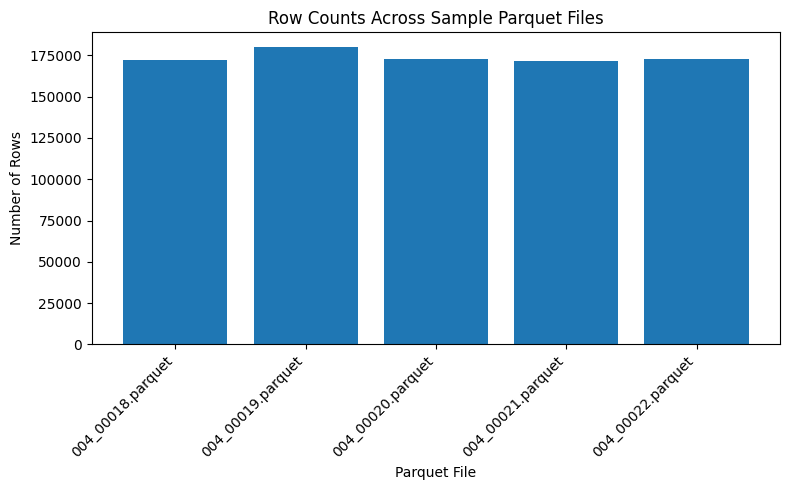

In [38]:
plt.figure(figsize=(8, 5))
plt.bar(file_comparison_df["file"], file_comparison_df["rows"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of Rows")
plt.xlabel("Parquet File")
plt.title("Row Counts Across Sample Parquet Files")
plt.tight_layout()
plt.show()

## 10. Token Count Distribution

### English
The `token_count` column is likely to be useful for later quality checks and filtering.  
I inspect its distribution to understand how short or long the sample documents are.

### 中文
`token_count` 字段后续很可能对质量检查和过滤有帮助。  
这里先查看它的分布，以了解当前样本文档的长短差异。

In [39]:
df["token_count"].describe()

count     1000.000000
mean       810.145000
std       2102.038911
min         43.000000
25%        240.000000
50%        511.000000
75%        918.000000
max      62381.000000
Name: token_count, dtype: float64

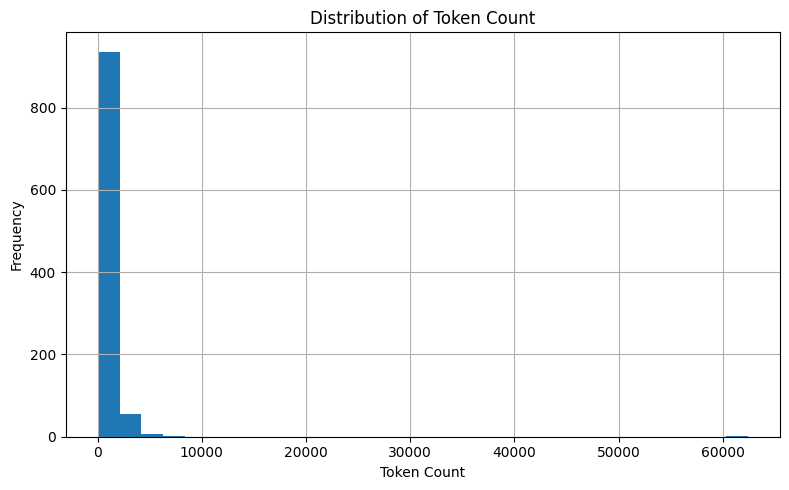

In [40]:
plt.figure(figsize=(8, 5))
df["token_count"].hist(bins=30)
plt.xlabel("Token Count")
plt.ylabel("Frequency")
plt.title("Distribution of Token Count")
plt.tight_layout()
plt.show()

In [24]:
# Compare whether the column names are consistent across a few files
schema_records = []

for fp in parquet_files[:5]:
    pf_temp = pq.ParquetFile(fp)
    schema_records.append({
        "file": os.path.basename(fp),
        "schema_preview": str(pf_temp.schema).split("\n")[:8]
    })

schema_df = pd.DataFrame(schema_records)
schema_df

,file,schema_preview
0,004_00018.parquet,[<pyarrow._parquet.ParquetSchema object at 0x7...
1,004_00019.parquet,[<pyarrow._parquet.ParquetSchema object at 0x7...
2,004_00020.parquet,[<pyarrow._parquet.ParquetSchema object at 0x7...
3,004_00021.parquet,[<pyarrow._parquet.ParquetSchema object at 0x7...
4,004_00022.parquet,[<pyarrow._parquet.ParquetSchema object at 0x7...


## 11. Language Score Distribution

### English
The `language_score` column may help indicate confidence in language identification.  
Inspecting this distribution can provide an early view of language-related consistency in the sample.

### 中文
`language_score` 字段可能反映语言识别的置信度。  
检查它的分布可以帮助初步了解当前 sample 在语言层面的一致性。

In [41]:
df["language_score"].describe()

count    1000.000000
mean        0.935543
std         0.039181
min         0.655934
25%         0.919891
50%         0.942585
75%         0.961820
max         0.995808
Name: language_score, dtype: float64

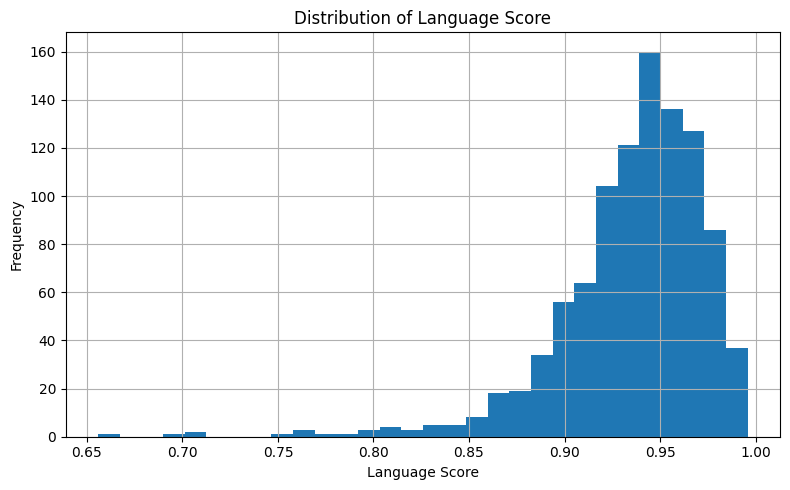

In [42]:
plt.figure(figsize=(8, 5))
df["language_score"].hist(bins=30)
plt.xlabel("Language Score")
plt.ylabel("Frequency")
plt.title("Distribution of Language Score")
plt.tight_layout()
plt.show()

## 12. Source / Domain Snapshot

### English
The `url` column can also provide a rough view of source diversity.  
Here I extract domains from URLs and inspect the most frequent ones in the sample.

### 中文
`url` 字段还可以帮助初步观察数据来源的多样性。  
这里从 URL 中提取 domain，并查看当前样本中最常见的来源。

In [43]:
# Extract domains from URL strings
df["domain"] = df["url"].astype(str).str.extract(r"https?://([^/]+)", expand=False)

top_domains = df["domain"].value_counts().head(10)
top_domains

domain
escapefan.com                 4
news.windowstorussia.com      3
community.logos.com           3
maineartsjournal.com          3
optimaplacement.com           3
www.unemed.com                2
www.untappedcities.com        2
www.windowsbasics.com         2
xinfuswimwear.com             2
barbgreenberg.blogspot.com    2
Name: count, dtype: int64

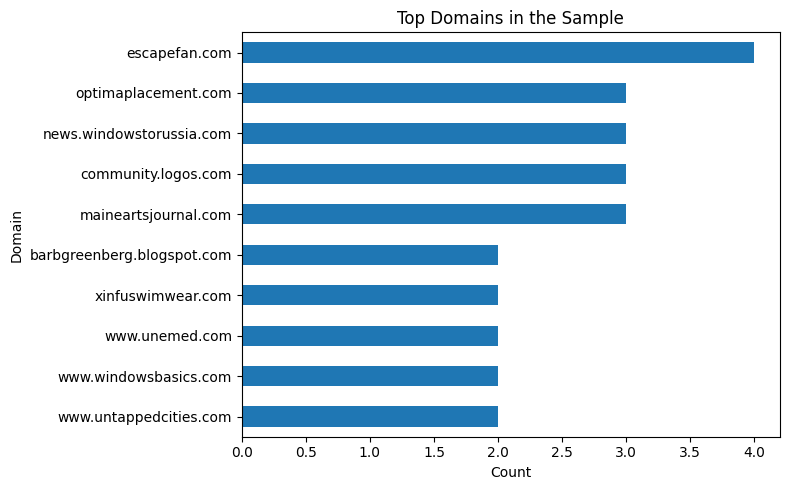

In [44]:
plt.figure(figsize=(8, 5))
top_domains.sort_values().plot(kind="barh")
plt.xlabel("Count")
plt.ylabel("Domain")
plt.title("Top Domains in the Sample")
plt.tight_layout()
plt.show()

## 13. Inspect Extreme Examples

### English
To better understand variation in the sample, I inspect a few very short and very long records based on `token_count`.  
These examples may be useful later when thinking about cleaning or filtering rules.

### 中文
为了更好地理解当前样本的差异，我根据 `token_count` 查看一些特别短和特别长的记录。  
这些样例在后续思考清洗或过滤规则时可能会有帮助。

In [45]:
# Shortest samples
df.nsmallest(5, "token_count")[["token_count", "language_score", "url", "text"]]

,token_count,language_score,url,text
538,43,0.866427,https://events.udel.edu/event/superstar_sellin...,"Friday, March 12, 2021 2pm to 3pm\nAbout this ..."
775,62,0.914122,https://louizeclark.com/m/login?r=%2Fm%2Faccount,Signed in as:\nSign in to your account to acce...
206,67,0.840870,https://ads.tiktok.com/business/en-GB/products...,Campaign solutions designed to boost visibilit...
203,69,0.876219,https://abracadabranyc.com/products/glamour-ey...,These Femme Fatale #47 Eyelashes offer full vo...
760,69,0.790165,https://lemken.com/en-en/agrovision/agricultur...,Rubin 10 MR/TF\n240 years LEMKEN\nOur driving ...


In [46]:
# Longest samples
df.nlargest(5, "token_count")[["token_count", "language_score", "url", "text"]]

,token_count,language_score,url,text
905,62381,0.947122,https://pdfcoffee.com/2pac-vs-biggie-an-illust...,CONTENTS Preface Chapter 1 PORTRAITS OF THE AR...
298,7424,0.900291,https://bellebeautyhacks.com/3c-4a-hairstyles/,Styling 3c/4a hairstyles when you’re running l...
854,6019,0.970273,https://newsroom.iium.edu.my/TWrfWzYr-natural-...,After seeing natural sex supplements Gauss mor...
800,5149,0.921754,https://mennblech.at/uncategorized/how-to-crea...,"Mostbet Registration, Login, Plus Account Veri..."
940,4588,0.944997,https://publications.parliament.uk/pa/cm201415...,"Business, Innovation and Skills CommitteeWritt..."


## 14. Initial Observations

### English
Based on the exploration above, I can make several initial observations:
- the parquet files can be located and inspected successfully in the current environment,
- the selected sample file has a clear and stable schema with 9 columns,
- the sampled shards appear structurally consistent in row counts, column counts, and column names,
- missingness is minimal in the current sample,
- `token_count` shows substantial variation, suggesting a wide range of document lengths,
- `language_score` is generally high, although there is still some variation,
- the sample also includes a diverse set of source domains.

### 中文
基于以上探索，可以形成以下初步观察：
- 可以在当前环境中成功定位并检查 parquet 文件，
- 当前选定 sample 文件具有清晰且稳定的 9 列 schema，
- 抽样比较表明不同分片在行数、列数和字段名称上基本一致，
- 当前样本中的缺失值很少，
- `token_count` 存在较大差异，说明文档长度分布范围较广，
- `language_score` 整体较高，但仍存在一定波动，
- 当前样本还表现出一定的数据来源多样性。

## 15. Limitations of This V1 Exploration

### English
This notebook is still a first-pass exploration only.  
Current limitations include:
- the analysis is based on a limited subset of parquet files,
- most checks are still exploratory rather than decision-oriented,
- no formal cleaning workflow has been applied yet,
- source diversity and extreme examples have only been inspected at a surface level.

### 中文
本 notebook 目前仍然只是第一轮探索。  
当前局限包括：
- 分析范围仅基于有限数量的 parquet 文件子集，
- 当前检查仍以探索为主，而不是面向正式决策，
- 尚未正式加入完整的数据清洗流程，
- 对来源多样性和极端样本的观察目前还比较表层。

## 16. Next Steps

### English
Possible next steps after this notebook:
1. inspect more shards instead of mainly relying on one file,
2. investigate key fields such as `text`, `token_count`, and `language_score` more carefully,
3. extend the analysis from structure-level checks to content-level checks,
4. design simple cleaning rules for unusually short, long, or low-confidence records,
5. connect exploration results to later training-data preparation.

### 中文
本 notebook 之后可以继续推进的方向包括：
1. 分析更多分片，而不是主要依赖单个文件，
2. 更细致地检查 `text`、`token_count` 和 `language_score` 等关键字段，
3. 将探索从结构层面扩展到内容层面，
4. 针对异常短、异常长或低置信度样本设计基础清洗规则，
5. 将当前探索结果进一步连接到后续训练数据准备流程。